# 4. Multivariate Analysis

In line with Step 4 of the OECD Handbook on Constructing Composite Indicators, this section examines the underlying structure of the dataset. Multivariate techniques are applied to assess whether the theoretical grouping of indicators is supported by the data, and to inform the weighting and aggregation approach.

### Methodological Objectives:
1. **Sub-index coherence**:
Assess the relationships between indicators within each sub-index to determine whether they behave as consistent groups.
2. **Dimensionality reduction**:
Apply Principal Component Analysis (PCA) to identify the main underlying drivers of variation across all indicators.

## 4.1 Correlation Analysis Setup and Methodology

To assess the internal structure of the composite indicator, all variables were first standardised using Z-score normalisation. This ensures that indicators with different units and scales can be directly compared on a consistent basis.

Following standardisation, pairwise Pearson correlation coefficients were calculated within each sub-index. These correlations measure the strength and direction of linear relationships between indicators.

To support interpretation, visual scatter plots with fitted linear trendlines were generated for all variable pairs. Each plot displays both the distribution of observations and the corresponding correlation value.

This step provides an initial analysis of:
- relationships between indicators within each sub-index
- potential redundancy between variables
- the overall coherence of the conceptual framework

The results are presented in Section 4.2.

In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
from sklearn.preprocessing import StandardScaler

imputed_data_path = "../data/worldbank_imputed_data.csv"

In [ ]:
# Readable names for each indicator
short_labels = {
    "credit_to_private_sector": "Domestic Credit to Private Sector (% of GDP)",
    "fdi_inflows": "Foreign Direct Investment, Net Inflows (% of GDP)",
    "market_capitalisation": "Market Capitalization of Listed Domestic Companies (% of GDP)",
    "stock_market_liquidity": "Stocks Traded, Total Value (% of GDP)",
    "broadband_subscriptions": "Fixed Broadband Subscriptions (per 100 people)",
    "internet_usage_rate": "Individuals Using the Internet (% of population)",
    "secure_servers_density": "Secure Internet Servers (per 1 million people)",
    "rd_expenditure": "Research and Development (R&D) Expenditure (% of GDP)",
    "gdp_growth": "GDP Growth (annual %)",
    "inflation_rate": "Inflation, Consumer Prices (annual %)",
    "real_interest_rate": "Real Interest Rate (%)",
    "capital_formation": "Gross Fixed Capital Formation (% of GDP)",
    "tertiary_enrollment": "School Enrollment, Tertiary (% gross)",
    "labor_productivity": "GDP Per Person Employed (constant 2021 PPP $)",
    "high_tech_exports": "High-Technology Exports (% of manufactured exports)",
    "ict_imports": "ICT Goods Imports (% total goods imports)"
}

# Group variables into sub-indices
sub_indices = {
    "Finance & Investment": [
        "credit_to_private_sector", "fdi_inflows",
        "market_capitalisation", "stock_market_liquidity"
    ],
    "Technology & Innovation": [
        "broadband_subscriptions", "internet_usage_rate",
        "secure_servers_density", "rd_expenditure"
    ],
    "Economic Growth & Stability": [
        "gdp_growth", "inflation_rate",
        "real_interest_rate", "capital_formation"
    ],
    "Talent & Productivity": [
        "tertiary_enrollment", "labor_productivity",
        "high_tech_exports", "ict_imports"
    ]
}


Sub-Index: Finance & Investment
--------------------------------------------------


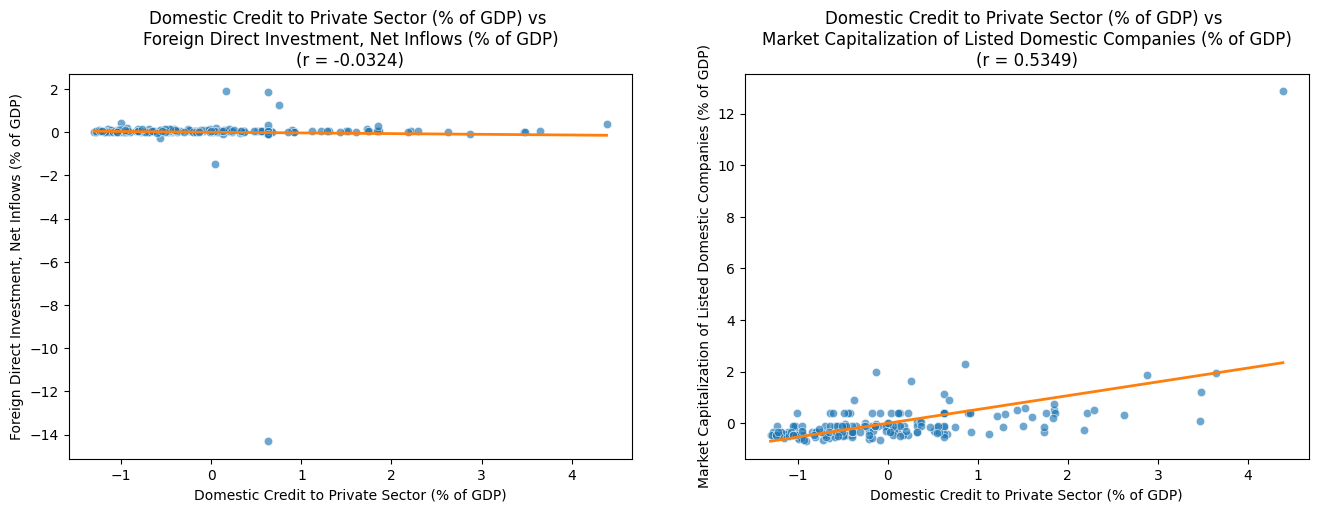

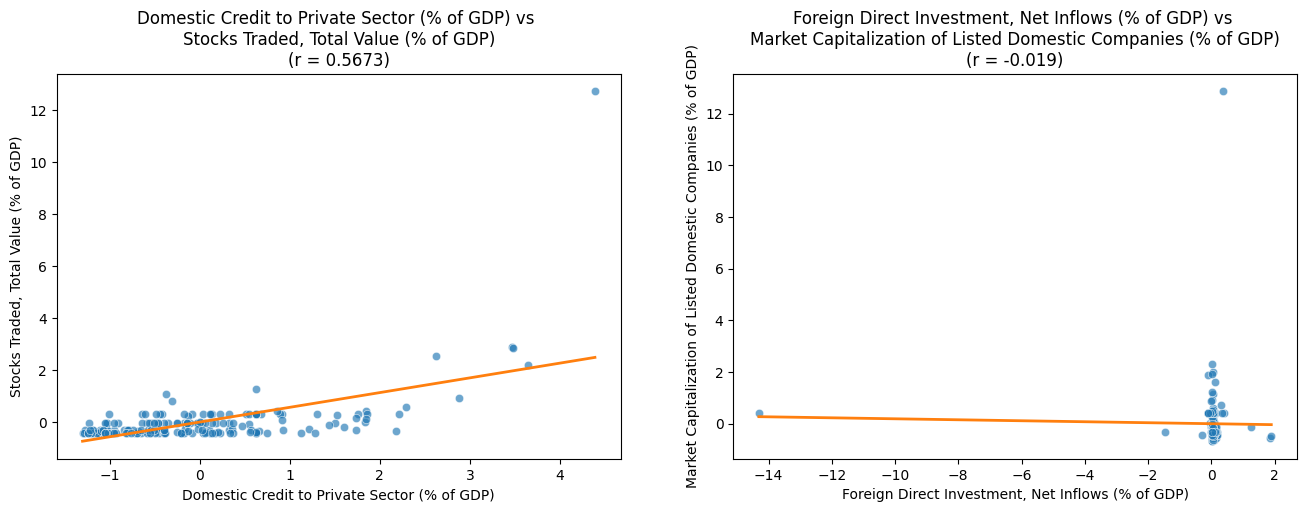

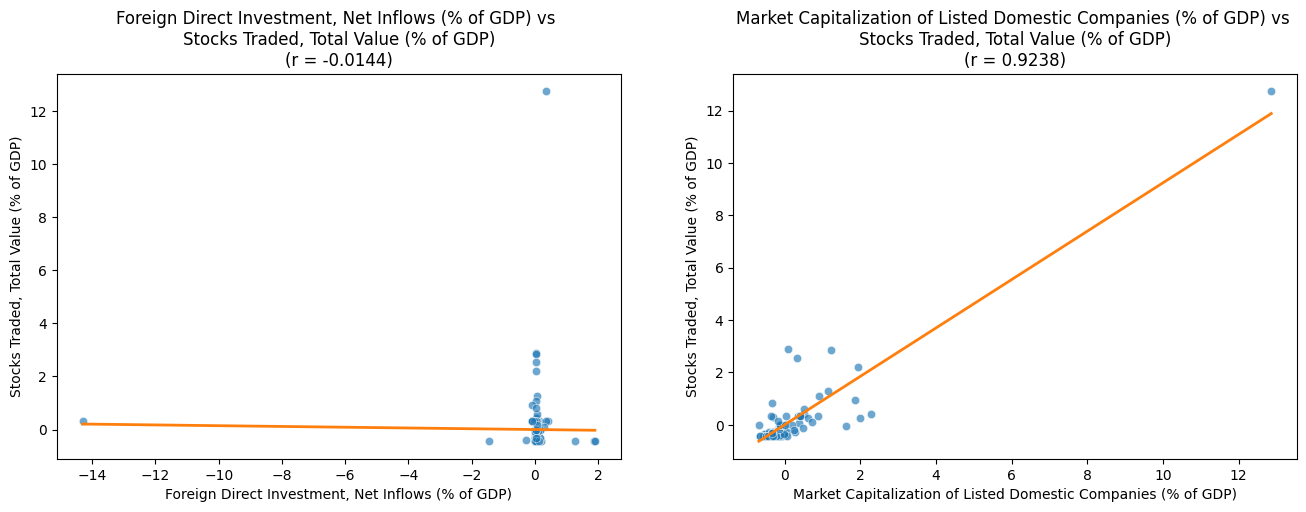


Sub-Index: Technology & Innovation
--------------------------------------------------


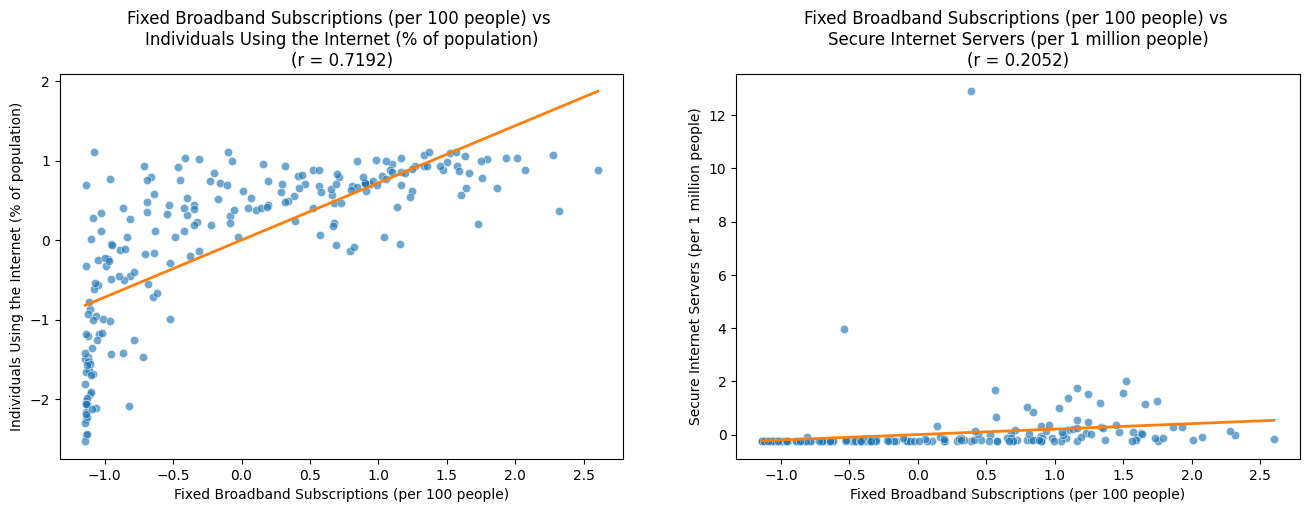

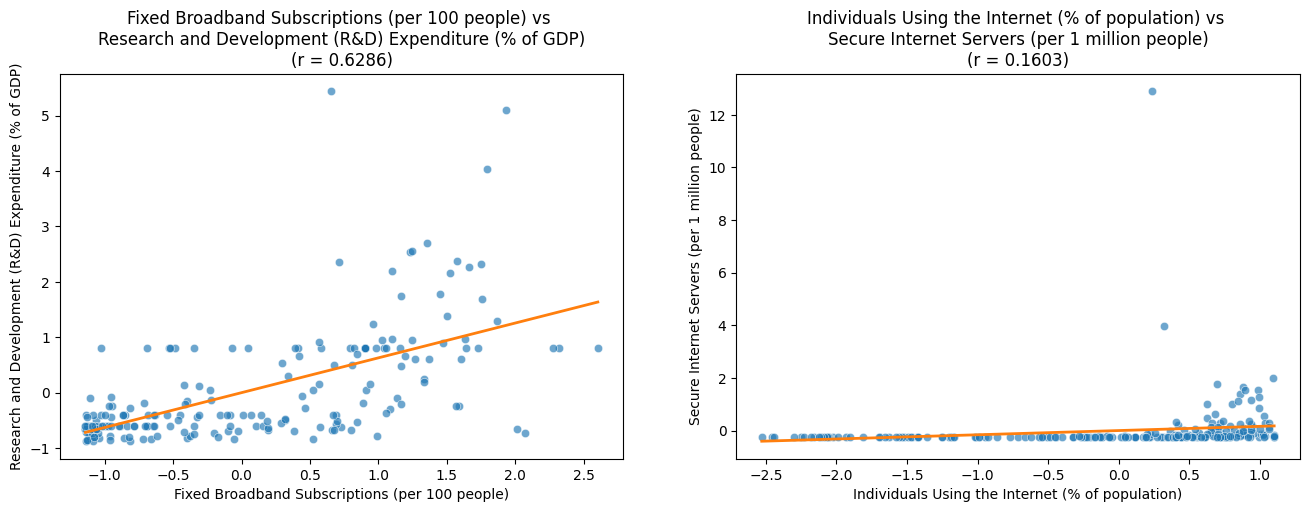

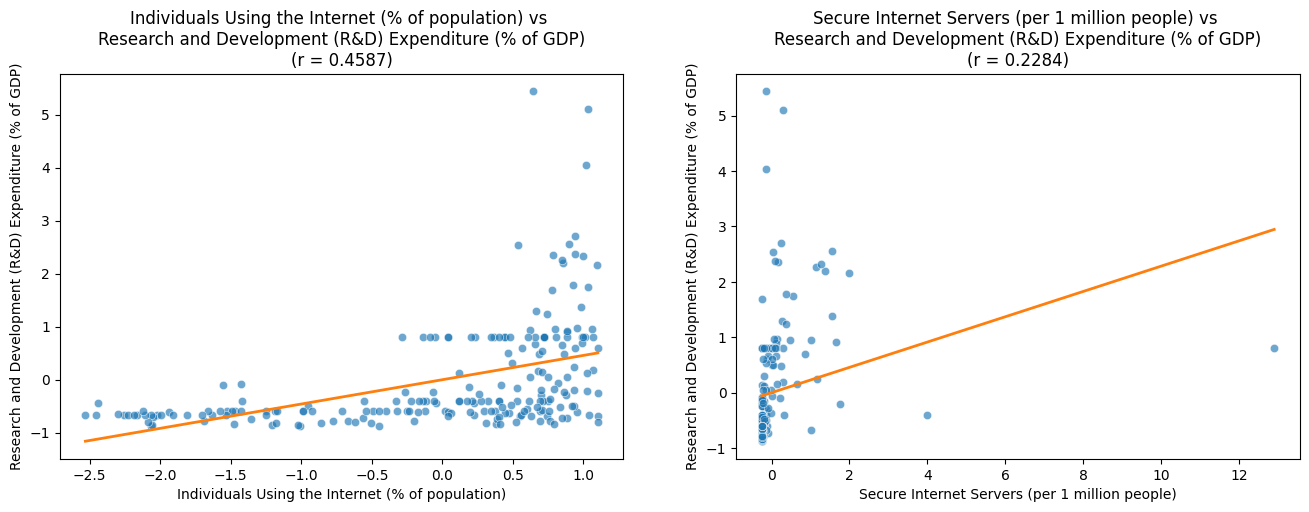


Sub-Index: Economic Growth & Stability
--------------------------------------------------


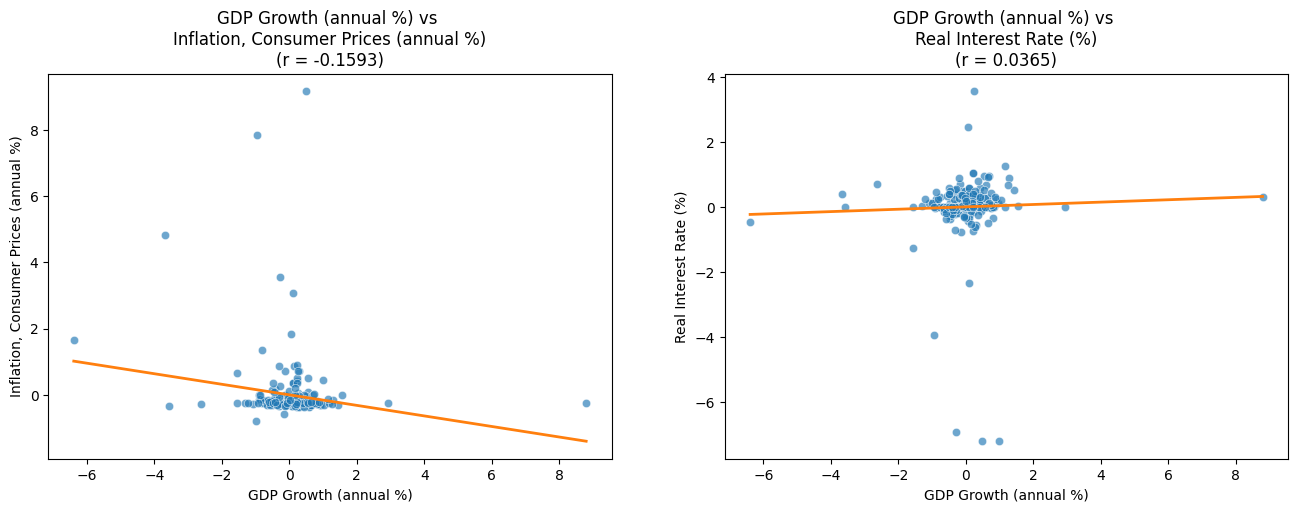

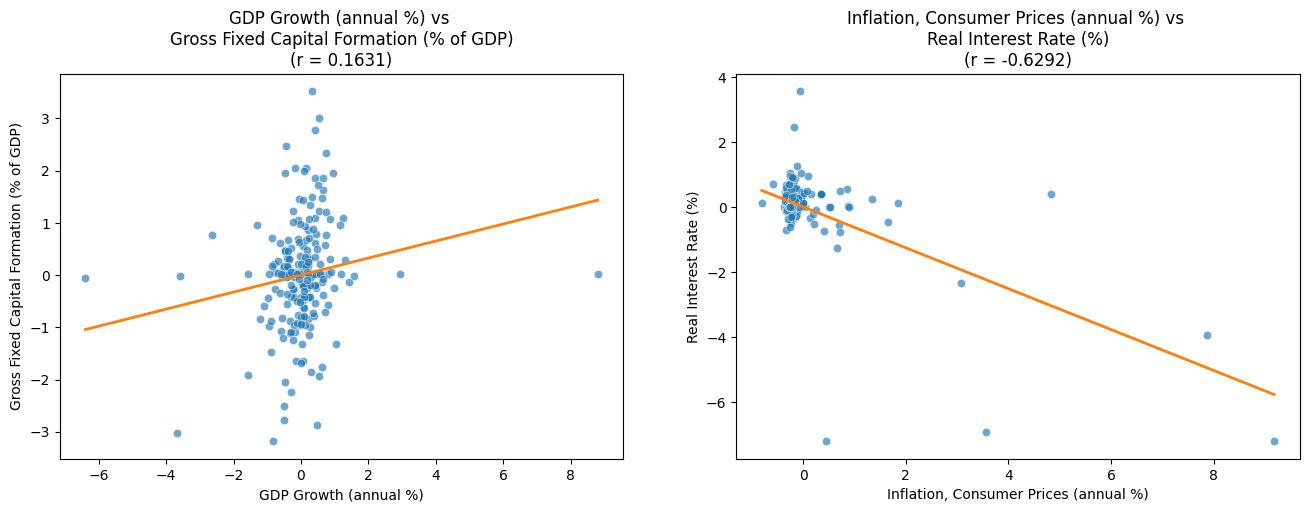

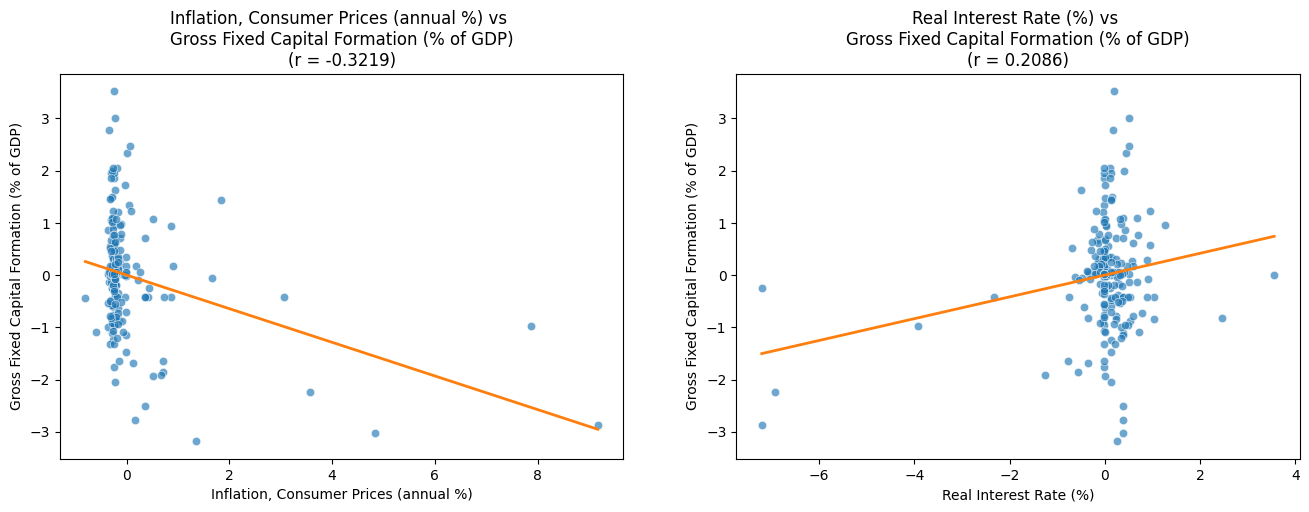


Sub-Index: Talent & Productivity
--------------------------------------------------


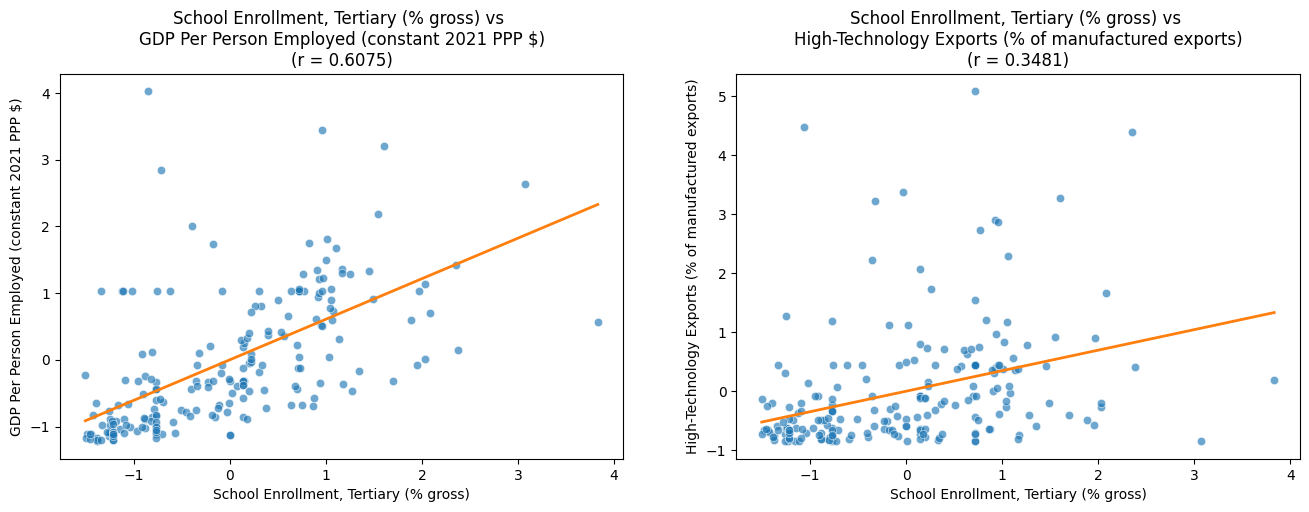

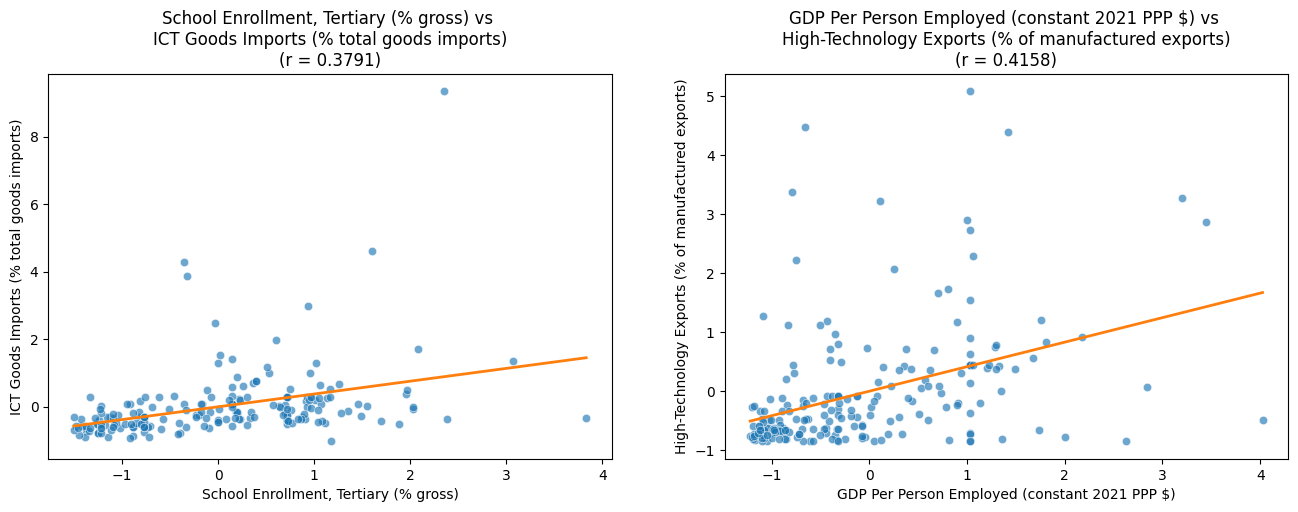

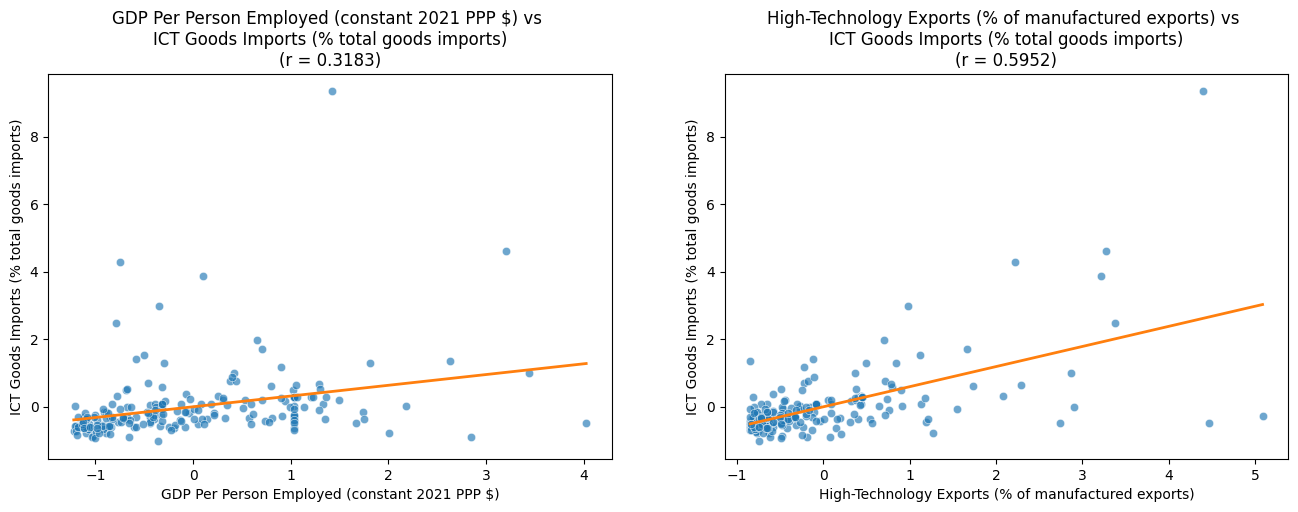

In [ ]:
if not os.path.exists(imputed_data_path):
    print(f"'{imputed_data_path}' not found. Run Section 3 code first.")
else:
    df_snapshot = pd.read_csv(imputed_data_path)

    # Select only numeric columns for scaling 
    exclude_cols = ['Country Name', 'Country Code', 'Income Group']
    numeric_cols = [col for col in df_snapshot.columns if col not in exclude_cols]

    # Standardize values using Z-score (makes variables comparable)
    scaler = StandardScaler()
    scaled_values = scaler.fit_transform(df_snapshot[numeric_cols])
    df_scaled = pd.DataFrame(
        scaled_values,
        columns=numeric_cols,
        index=df_snapshot['Country Code']
    )

    # Pairwise correlation plots within each sub-index
    for sub_name, codes in sub_indices.items():
        print(f"\nSub-Index: {sub_name}")
        print("-" * 50)

        # Get readable labels for this group
        labels = [short_labels[code] for code in codes]
        pairs = list(combinations(labels, 2))

        # Loop through all pairs, 2 plots per row
        for i in range(0, len(pairs), 2):
            fig, axes = plt.subplots(1, 2, figsize=(16, 5)) 
            # fig.subplots_adjust(wspace=0.3, hspace=0.3) 

            for j, ax in enumerate(axes):
                if i + j >= len(pairs):
                    ax.axis("off")  
                    continue

                var1_label, var2_label = pairs[i + j]

                # Convert labels back to column names
                code1 = [k for k, v in short_labels.items() if v == var1_label][0]
                code2 = [k for k, v in short_labels.items() if v == var2_label][0]

                x_data = df_scaled[code1]
                y_data = df_scaled[code2]

                # Calculate correlation
                r_val = x_data.corr(y_data, method='pearson')

                # Scatter plot
                ax.scatter(
                    x_data,
                    y_data,
                    alpha=0.65,
                    color="#1f77b4",  
                    edgecolors="white",
                    linewidth=0.5
                )

                # Trend line (linear fit)
                unique_x = np.unique(x_data)
                trendline = np.poly1d(np.polyfit(x_data, y_data, 1))(unique_x)
                ax.plot(
                    unique_x,
                    trendline,
                    color="#ff7f0e", 
                    linewidth=2
                )

                title_text = f"{var1_label} vs \n{var2_label}\n(r = {round(r_val, 4)})"
                ax.set_title(title_text, fontsize=12)

                # Axis labels
                ax.set_xlabel(var1_label, fontsize=10)
                ax.set_ylabel(var2_label, fontsize=10)

            plt.show()

## 4.2. Pairwise Correlation Results Within Sub-Indices

### 4.2.1 Finance & Investment

- **Domestic Credit vs FDI:** No linear relationship (very weak correlation)  
- **Domestic Credit vs Market Capitalisation:** Moderate positive correlation  
- **Domestic Credit vs Stocks Traded:** Moderate positive correlation  

- **FDI vs Market Capitalisation:** No linear relationship  
- **FDI vs Stocks Traded:** No linear relationship  

- **Market Capitalisation vs Stocks Traded:** Very strong positive correlation (high redundancy, both capture similar market activity)


### 4.2.2 Technology & Innovation

- **Broadband vs Internet Usage:** Strong positive correlation (higher infrastructure aligns with higher usage)  
- **Broadband vs Secure Servers:** Weak positive correlation  
- **Broadband vs R&D Expenditure:** Moderate positive correlation  

- **Internet Usage vs Secure Servers:** Weak positive correlation  
- **Internet Usage vs R&D Expenditure:** Moderate positive correlation  

- **Secure Servers vs R&D Expenditure:** Weak positive correlation  


### 4.2.3 Economic Growth & Stability

- **GDP Growth vs Inflation:** Weak negative correlation (higher inflation slightly reduces growth)  
- **GDP Growth vs Real Interest Rate:** No linear relationship  
- **GDP Growth vs Capital Formation:** Weak positive correlation  

- **Inflation vs Real Interest Rate:** Strong negative correlation (higher inflation reduces real returns)  
- **Inflation vs Capital Formation:** Moderate negative correlation  

- **Real Interest Rate vs Capital Formation:** Weak positive correlation  


### 4.2.4 Talent & Productivity

- **Tertiary Enrollment vs Labor Productivity:** Strong positive correlation (education improves productivity)  
- **Tertiary Enrollment vs High-Tech Exports:** Moderate positive correlation  
- **Tertiary Enrollment vs ICT Imports:** Moderate positive correlation  

- **Labor Productivity vs High-Tech Exports:** Moderate positive correlation  
- **Labor Productivity vs ICT Imports:** Moderate positive correlation  

- **High-Tech Exports vs ICT Imports:** Moderate to strong positive correlation (countries both import and export tech goods in integrated supply chains)

## 4.3. Heatmap Correlation Matrix Analysis

To further evaluate the internal structure of the dataset, I will generate Pearson correlation heatmaps for each sub-index and for the full global framework. These heatmaps will help visualize the strength and direction of relationships between indicators, allowing clearer identification of strong associations, weak interactions, and potential redundancy across the framework.

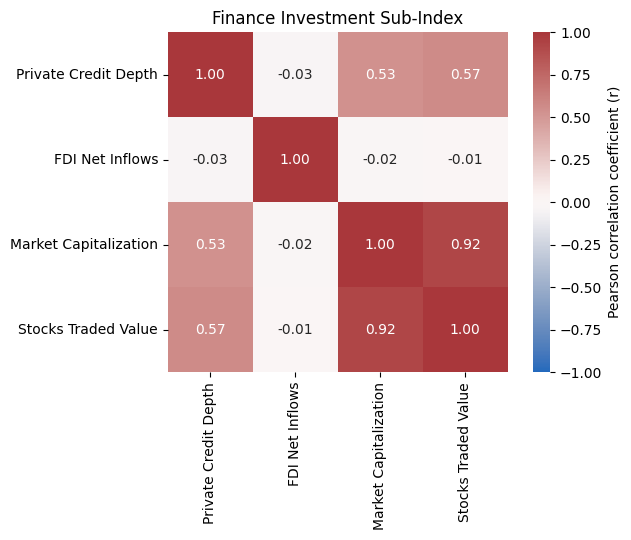

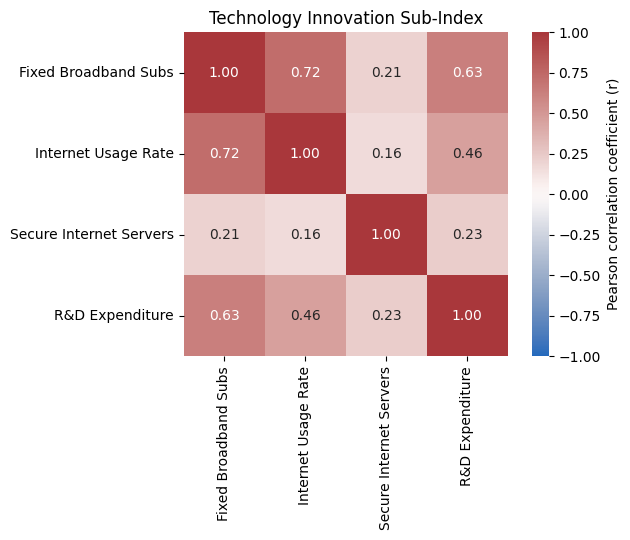

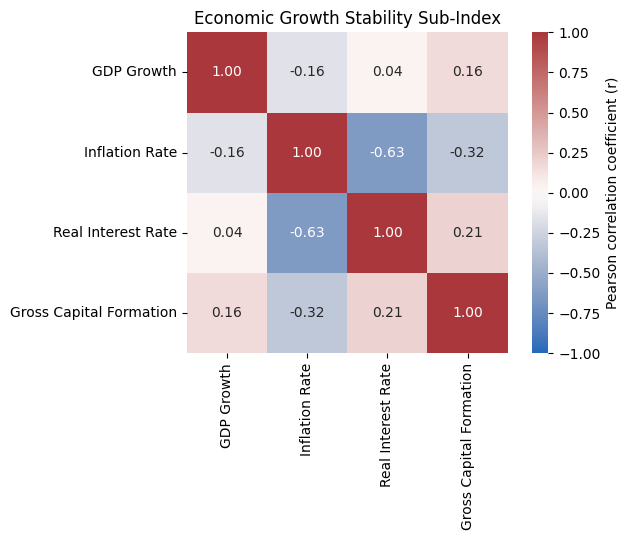

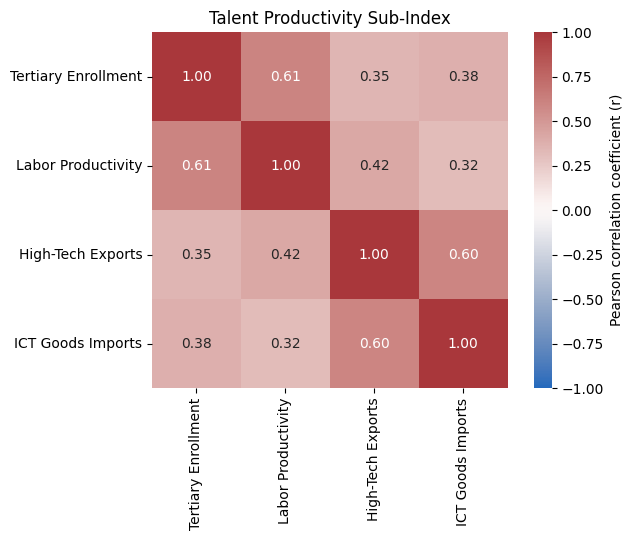

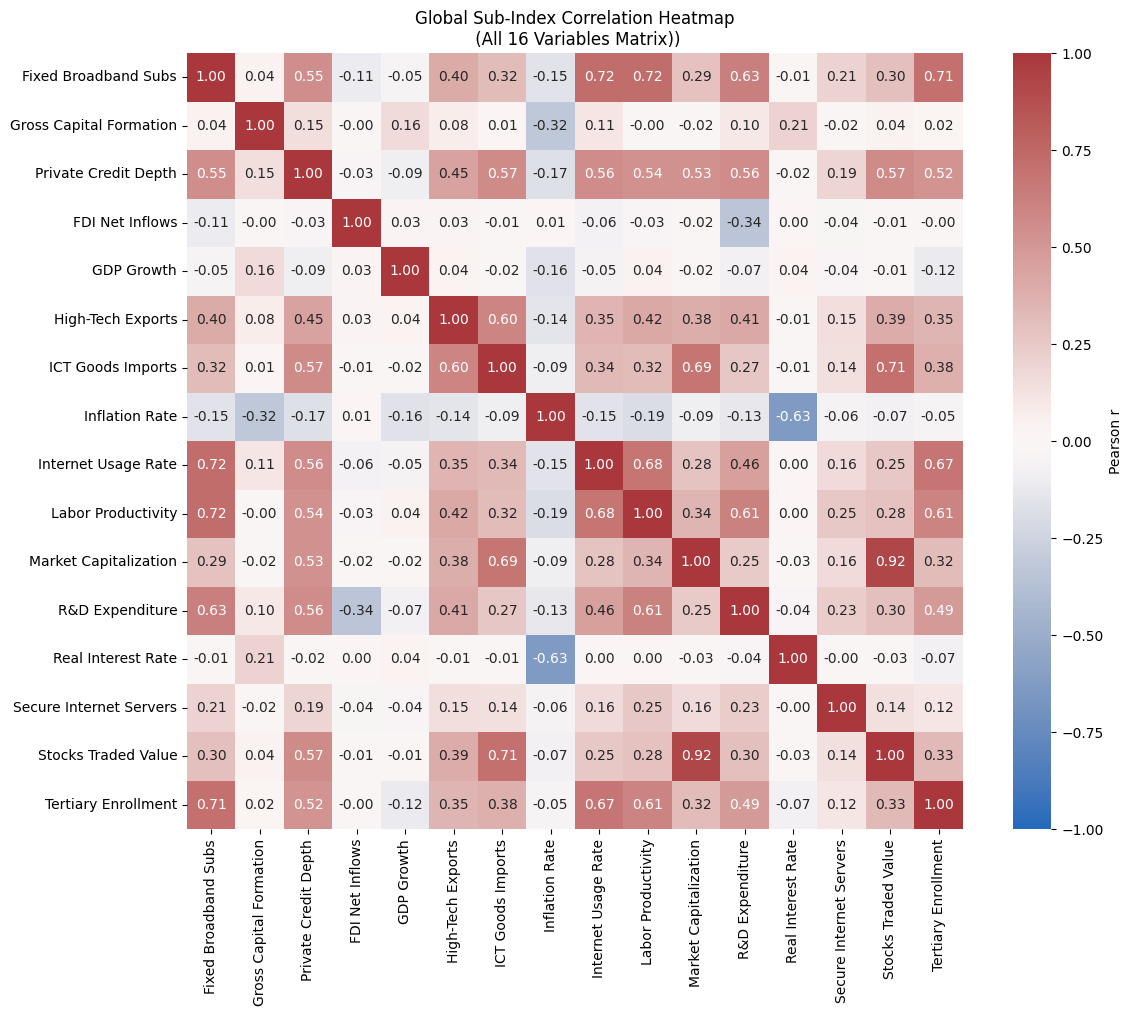

In [31]:
output_figure_dir = "../artifacts/correlations"
os.makedirs(output_figure_dir, exist_ok=True)

if not os.path.exists(imputed_data_path):
    print(f"'{imputed_data_path}' not found. Run Section 3 code first.")
else:
    df_snapshot = pd.read_csv(imputed_data_path)
    
    exclude_cols = ['Country Name', 'Country Code', 'Income Group']
    numeric_cols = [col for col in df_snapshot.columns if col not in exclude_cols]
    
    # Short labels for heatmap readability
    short_labels = {
        "credit_to_private_sector": "Private Credit Depth",
        "fdi_inflows": "FDI Net Inflows",
        "market_capitalisation": "Market Capitalization",
        "stock_market_liquidity": "Stocks Traded Value",
        "broadband_subscriptions": "Fixed Broadband Subs",
        "internet_usage_rate": "Internet Usage Rate",
        "secure_servers_density": "Secure Internet Servers",
        "rd_expenditure": "R&D Expenditure",
        "gdp_growth": "GDP Growth",
        "inflation_rate": "Inflation Rate",
        "real_interest_rate": "Real Interest Rate",
        "capital_formation": "Gross Capital Formation",
        "tertiary_enrollment": "Tertiary Enrollment",
        "labor_productivity": "Labor Productivity",
        "high_tech_exports": "High-Tech Exports",
        "ict_imports": "ICT Goods Imports"
    }
    
    # Rename columns for cleaner heatmaps
    df_mapped = df_snapshot[numeric_cols].rename(columns=short_labels)

    # Re-map sub-index grouping using the short titles
    sub_indices = {
        "finance_investment": [
            "Private Credit Depth", "FDI Net Inflows", "Market Capitalization", "Stocks Traded Value"
        ],
        "technology_innovation": [
            "Fixed Broadband Subs", "Internet Usage Rate", "Secure Internet Servers", "R&D Expenditure"
        ],
        "economic_growth_stability": [
            "GDP Growth", "Inflation Rate", "Real Interest Rate", "Gross Capital Formation"
        ],
        "talent_productivity": [
            "Tertiary Enrollment", "Labor Productivity", "High-Tech Exports", "ICT Goods Imports"
        ]
    }

    # Reusable heatmap plotting function
    def generate_heatmap(group_id, variables, dataframe):
        corr_matrix = dataframe[variables].corr(method="pearson")
        
        plt.figure(figsize=(7, 5.5))
        sns.heatmap(
            corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="vlag", 
            vmin=-1, 
            vmax=1,
            center=0,
            square=True,
            cbar_kws={"label": "Pearson correlation coefficient (r)"}
        )
        
        clean_title = group_id.replace('_', ' ').title()
        plt.title(f"{clean_title} Sub-Index")
        plt.tight_layout()
        
        save_path = os.path.join(output_figure_dir, f"heatmap_{group_id}.png")
        plt.savefig(save_path, dpi=300)
        plt.show()
        plt.close()

    # Loop through each sub-index
    for sub_id, feature_list in sub_indices.items():
        generate_heatmap(sub_id, feature_list, df_mapped)

    # Generate global correlation heatmap
    plt.figure(figsize=(12, 10))
    global_corr = df_mapped.corr(method="pearson")
    
    sns.heatmap(
        global_corr, 
        annot=True, 
        fmt=".2f", 
        cmap="vlag", 
        vmin=-1, 
        vmax=1, 
        center=0,
        square=True,
        cbar_kws={"label": "Pearson r"}
    )
    plt.title("Global Sub-Index Correlation Heatmap\n (All 16 Variables Matrix))")
    plt.tight_layout()
    
    global_save_path = os.path.join(output_figure_dir, "heatmap_global_landscape.png")
    plt.savefig(global_save_path, dpi=300)
    plt.show()
    plt.close()

## Heatmap Correlation Matrix Interpretations

### 4.3.1. Finance & Investment - Key Correlations
* **Market Capitalization and Stocks Traded Value ($r = 0.92$):** Very strong positive relationship. Countries with larger stock markets also tend to have much higher trading activity. These two indicators may be measuring very similar financial market conditions.
* **Private Credit Depth and Stocks Traded Value ($r = 0.57$):** Moderate positive relationship. Countries with stronger banking credit systems generally show more active stock market trading.
* **Private Credit Depth and Market Capitalization ($r = 0.54$):** Moderate positive correlation. Strong domestic lending systems are often linked with larger public equity markets.
* **FDI Net Inflows and Other Financial Indicators ($|r| < 0.04$):** Very weak relationships overall. Foreign direct investment appears to behave independently from domestic banking and stock market activity.

### 4.3.2. Technology & Innovation - Key Correlations
* **Fixed Broadband Subscriptions and Internet Usage Rate ($r = 0.72$):** Strong positive relationship. Countries with better broadband access usually have higher internet usage across the population.
* **Fixed Broadband Subscriptions and R&D Expenditure ($r = 0.63$):** Strong positive relationship. Economies with stronger digital infrastructure also tend to invest more in research and development.
* **Internet Usage Rate and R&D Expenditure ($r = 0.46$):** Moderate positive relationship. Higher internet adoption is generally linked with stronger innovation investment.
* **Secure Internet Servers and Other Indicators ($|r| \le 0.23$):** Weak correlations overall. Secure server infrastructure appears to capture a more specialized aspect of digital development.

### 4.3.3. Economic Growth & Stability - Key Correlations
* **Inflation Rate and Real Interest Rate ($r = -0.63$):** Strong negative relationship. Higher inflation is generally associated with lower real interest rates.
* **Inflation Rate and Gross Capital Formation ($r = -0.32$):** Moderate negative relationship. Countries with high inflation tend to show lower levels of long-term investment activity.
* **Real Interest Rate and Gross Capital Formation ($r = 0.21$):** Weak positive relationship. More stable real returns are slightly linked with higher capital investment.
* **GDP Growth and Other Indicators ($|r| \le 0.16$):** Weak relationships overall. Annual GDP growth does not show strong direct connections with the other stability indicators.

### 4.3.4. Talent & Productivity - Key Correlations
* **Tertiary Enrollment and Labor Productivity ($r = 0.61$):** Strong positive relationship. Countries with higher university enrollment tend to achieve greater productivity per worker.
* **High-Tech Exports and ICT Goods Imports ($r = 0.60$):** Strong positive relationship. Economies importing more ICT goods also tend to export more high-technology products.
* **Labor Productivity and High-Tech Exports ($r = 0.42$):** Moderate positive relationship. More productive economies are generally more competitive in advanced technology exports.
* **Tertiary Enrollment and ICT Goods Imports ($r = 0.38$):** Moderate positive relationship. Countries with stronger education systems tend to use more imported digital technologies.

### 4.3.5. Cross Sub-Indices Global Relationships
* **Market Capitalization and ICT Goods Imports ($r = 0.69$):** Strong positive relationship. Countries with larger financial markets also tend to import more technology goods.
* **Fixed Broadband Subscriptions and Labor Productivity ($r = 0.72$):** Strong positive relationship. Better digital infrastructure is closely linked with higher worker productivity.
* **Internet Usage Rate and Labor Productivity ($r = 0.68$):** Strong positive relationship. Economies with more connected populations generally show stronger productivity performance.
* **Tertiary Enrollment and Fixed Broadband Subscriptions ($r = 0.71$):** Strong positive correlation. Countries with stronger education systems also tend to have better digital infrastructure.
* **FDI Net Inflows and R&D Expenditure ($r = -0.34$):** Moderate negative relationship. Countries with high domestic R&D spending do not necessarily attract higher foreign direct investment inflows.

## 4.4. Redundancy Assessment Using Variance Inflation Factors (VIF)

After examining pairwise correlations and heatmap relationships, I will now evaluate whether any indicators show excessive multicollinearity within the framework. While Pearson correlations identify relationships between two variables, they cannot fully capture situations where multiple indicators collectively measure the same underlying economic pattern.

To assess this more formally, I will calculate the Variance Inflation Factor (VIF) for indicators within each sub-index. VIF measures how strongly one variable can be predicted using the remaining variables in the same sub-index. Higher VIF values indicate greater redundancy and suggest that an indicator may overlap heavily with others in the framework.

In [38]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

if not os.path.exists(imputed_data_path):
    print(f"'{imputed_data_path}' not found. Ensure Section 3 code ran successfully.")
else:
    df_snapshot = pd.read_csv(imputed_data_path)
    
    # Map 4 sub-indices and variables
    sub_indices = {
        "Finance & Investment": [
            "credit_to_private_sector", "fdi_inflows", "market_capitalisation", "stock_market_liquidity"
        ],
        "Technology & Innovation": [
            "broadband_subscriptions", "internet_usage_rate", "secure_servers_density", "rd_expenditure"
        ],
        "Economic Growth & Stability": [
            "gdp_growth", "inflation_rate", "real_interest_rate", "capital_formation"
        ],
        "Talent & Productivity": [
            "tertiary_enrollment", "labor_productivity", "high_tech_exports", "ict_imports"
        ]
    }
    
    print("Variance Inflation Factor (VIF) Analysis: Sub-Index-Level")
    
    # Iterate through each sub-index
    for subindex_name, codes in sub_indices.items():
        print(f"\n>> Sub-Index: {subindex_name}")
        print("-" * 65)
        
        # Extract variables for the current sub-index and apply local Z-score scaling
        df_pillar = df_snapshot[codes].copy()
        df_pillar_scaled = (df_pillar - df_pillar.mean()) / df_pillar.std()
        
        # Calculate the Variance Inflation Factor for each variable 
        vif_df = pd.DataFrame()
        vif_df["Variable Name"] = codes
        vif_df["VIF Score"] = [
            variance_inflation_factor(df_pillar_scaled.values, i) 
            for i in range(df_pillar_scaled.shape[1])
        ]
        
        # Check if VIF > 5.0
        vif_df["Status"] = vif_df["VIF Score"].apply(
            lambda x: "High Multicollinearity" if x > 5.0 else "Acceptable"
        )
        
        print(vif_df.round(4).to_string(index=False))
        print("-" * 65)

Variance Inflation Factor (VIF) Analysis: Sub-Index-Level

>> Sub-Index: Finance & Investment
-----------------------------------------------------------------
           Variable Name  VIF Score                 Status
credit_to_private_sector     1.4776             Acceptable
             fdi_inflows     1.0013             Acceptable
   market_capitalisation     6.8316 High Multicollinearity
  stock_market_liquidity     7.1919 High Multicollinearity
-----------------------------------------------------------------

>> Sub-Index: Technology & Innovation
-----------------------------------------------------------------
          Variable Name  VIF Score     Status
broadband_subscriptions     2.7124 Acceptable
    internet_usage_rate     2.0727 Acceptable
 secure_servers_density     1.0624 Acceptable
         rd_expenditure     1.6820 Acceptable
-----------------------------------------------------------------

>> Sub-Index: Economic Growth & Stability
-----------------------------------

### 4.4.1. Sub-Index - VIF Summary & Actions

The VIF results show that most indicators across the sub-indices do not suffer from serious multicollinearity. However, one issue appears in the Finance & Investment sub-index, where two variables show noticeable overlap.

* **Finance & Investment Sub-Index (Some Overlap Detected):**  
  `market_capitalisation` (VIF = 6.83) and `stock_market_liquidity` (VIF = 7.19) both exceed the threshold of 5.0. This suggests that they are capturing similar variation in equity market activity. In contrast, `credit_to_private_sector` (VIF = 1.48) and `fdi_inflows` (VIF = 1.00) show no meaningful multicollinearity and provide distinct information.

* **Technology & Innovation Sub-Index (No Issues):**  
  All variables are below the VIF threshold. The highest value is `broadband_subscriptions` (VIF = 2.71), which is still comfortably within acceptable limits.

* **Economic Growth & Stability Sub-Index (No Issues):**  
  Multicollinearity is low overall. The highest VIF is 1.80 for `inflation_rate`, which does not indicate any concern.

* **Talent & Productivity Sub-Index (No Issues):**  
  All variables show consistently low VIF values (around 1.6–1.7), suggesting that each indicator contributes separate information.

#### Action to Take

Based on these results, one adjustment will be made before PCA:

1. **Remove `stock_market_liquidity` from the final dataset.**  
   It is highly similar to `market_capitalisation`, so keeping both would effectively double-count the same aspect of equity market activity.

2. **Proceed with a 15 variables framework for PCA.**  
   After this adjustment, the dataset is suitable for dimensionality reduction without significant multicollinearity concerns.

In [39]:
pca_features = [
    # Finance & Investment
    "credit_to_private_sector",
    "fdi_inflows",
    "market_capitalisation",
    # "stock_market_liquidity",  # Dropped due to high VIF (multicollinearity)
    
    # Technology & Innovation
    "broadband_subscriptions",
    "internet_usage_rate",
    "secure_servers_density",
    "rd_expenditure",
    
    # Economic Growth & Stability
    "gdp_growth",
    "inflation_rate",
    "real_interest_rate",
    "capital_formation",
    
    # Talent & Productivity
    "tertiary_enrollment",
    "labor_productivity",
    "high_tech_exports",
    "ict_imports"
]

## 4.5. Principal Component Analysis (PCA) for Dimension Reduction

### 4.5.1. Introduction and Method

After checking for redundancy within each sub-index, I will now apply Principal Component Analysis (PCA) to reduce the number of variables and build a more compact set of indicators. PCA helps convert the remaining 15 correlated variables into a smaller number of uncorrelated components (called principal components). Each component captures part of the overall variation in the dataset, with the first few components explaining the most information.

To carry out this step, I will use three main checks:

* **Eigenvalues (Kaiser Criterion):**  
  I will look at the eigenvalues of each component and keep only those above 1.0. This ensures that each retained component explains more variation than a single original variable.

* **Scree Plot:**  
  I will visually inspect the scree plot to identify the “elbow point”, where the explained variance starts to level off. This helps confirm how many components should be kept, aiming to retain around 60–70% of the total variance.

* **Factor Loadings:**  
  I will examine the factor loadings to see how strongly each original variable contributes to the retained components. This helps interpret what each principal component represents in economic terms.

In [44]:
if not os.path.exists(imputed_data_path):
    print(f"'{imputed_data_path}' not found.")
else:
    df_snapshot = pd.read_csv(imputed_data_path)

    # Input for PCA
    df_snapshot = df_snapshot.dropna(subset=pca_features)

    # Standardize indicators
    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(df_snapshot[pca_features])

    df_pca_input = pd.DataFrame(
        scaled_array,
        columns=pca_features,
        index=df_snapshot["Country Code"]
    )

    # Fit PCA model
    pca_model = PCA()
    pca_model.fit(df_pca_input)

    # Eigenvalues 
    eigenvalues = pca_model.explained_variance_
    prop_variance = pca_model.explained_variance_ratio_
    cum_variance = np.cumsum(prop_variance)

    # PCA summary table
    pca_summary = pd.DataFrame({
        "Component": [f"PC{i+1}" for i in range(len(pca_features))],
        "Eigenvalue": eigenvalues,
        "Proportion of Variance": prop_variance,
        "Cumulative Variance": cum_variance
    })

    print("=======================================================================")
    print("                    PCA INITIAL VARIANCE EXTRACTION                    ")
    print("=======================================================================")
    print(pca_summary.round(4).to_string(index=False))
    print("=======================================================================")

                    PCA INITIAL VARIANCE EXTRACTION                    
Component  Eigenvalue  Proportion of Variance  Cumulative Variance
      PC1      5.0461                  0.3349               0.3349
      PC2      1.8570                  0.1232               0.4581
      PC3      1.4528                  0.0964               0.5545
      PC4      1.1066                  0.0734               0.6279
      PC5      1.0318                  0.0685               0.6964
      PC6      0.9541                  0.0633               0.7597
      PC7      0.8257                  0.0548               0.8145
      PC8      0.6438                  0.0427               0.8572
      PC9      0.4887                  0.0324               0.8897
     PC10      0.3554                  0.0236               0.9132
     PC11      0.3448                  0.0229               0.9361
     PC12      0.3213                  0.0213               0.9574
     PC13      0.2361                  0.0157            

#### 4.5.2. Eigenvalue Selection (Kaiser Criterion)

I calculated eigenvalues for all 15 standardized indicators to identify the main underlying dimensions in the data. I then apply the Kaiser Criterion, where I keep only components with eigenvalues greater than 1.0. This means each retained component must explain more variation than a single original variable.

The results show that five components meet this rule:

- **PC1 (λ = 5.0461)** explains 33.49% of the total variance and captures the main structure in the data.  
- **PC2 (λ = 1.8570)** and **PC3 (λ = 1.4528)** capture additional but smaller patterns, explaining 12.32% and 9.64%.  
- **PC4 (λ = 1.1066)** and **PC5 (λ = 1.0318)** still meet the threshold but represent weaker underlying patterns.  

All remaining components (PC6 to PC15) fall below 1.0, meaning they do not explain more variance than a single variable and mainly capture noise or minor variation.

Based on this, I retain the first five components. Together, they explain 69.64% of the total variance, which is within the typical 60–70% range used in composite index construction.


#### 4.5.3. Scree Plot 

To decide how many principal components to keep, I use a scree plot that shows the eigenvalues for all 15 components.

Each eigenvalue represents how much variance a component explains. I compare these values against the Kaiser rule threshold of 1.0, which is a standard cutoff for identifying meaningful components.

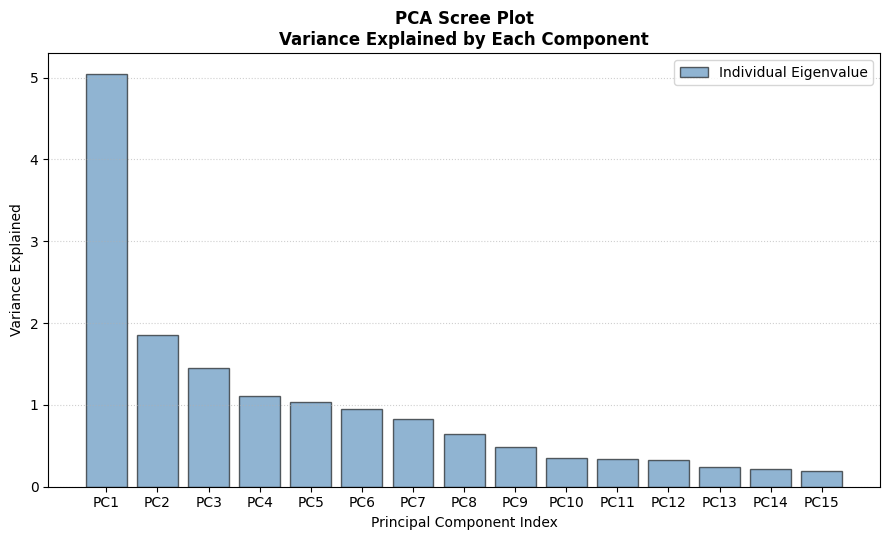

In [48]:
output_figure_dir = "../artifacts/figures"
os.makedirs(output_figure_dir, exist_ok=True)

plt.figure(figsize=(9, 5.5))

# Bar chart for individual component variance 
plt.bar(range(1, 16), eigenvalues, alpha=0.6, color='steelblue', 
        edgecolor='black', label='Individual Eigenvalue')

plt.title("PCA Scree Plot\nVariance Explained by Each Component", fontsize=12, fontweight='bold')
plt.xlabel("Principal Component Index", fontsize=10)
plt.ylabel("Variance Explained", fontsize=10)
plt.xticks(range(1, 16), [f"PC{i}" for i in range(1, 16)])
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

save_path = os.path.join(output_figure_dir, "pca_scree_plot.png")
plt.savefig(save_path, dpi=300)
plt.show()
plt.close()

The plot shows a steep drop from PC1 to PC3, followed by a gradual flattening. After PC5, all eigenvalues fall below 1.0, meaning they explain less variation than a single original variable.

Based on this pattern, I retain the first five components, as they capture most of the meaningful structure in the data while keeping the model compact. 

### 4.5.4. PCA Country Scatter Plot (PC1 vs PC2)

To better understand the structure captured by PCA, I project each country onto the first two principal components.

Each point represents a country, positioned based on its scores on PC1 and PC2. PC1 captures the strongest overall variation in the dataset, while PC2 captures a secondary independent pattern.

Countries are coloured by income group to check whether the PCA space reflects meaningful economic differences between development levels.

The dashed horizontal and vertical lines at zero represent the global mean. Countries close to the origin have more average profiles across the indicators, while those further away show stronger deviations from the global pattern.

Overall, the scatter plot provides a clear visual summary of how countries cluster based on the underlying economic structure captured by PCA, and whether income groups form distinct or overlapping patterns in this reduced-dimensional space.

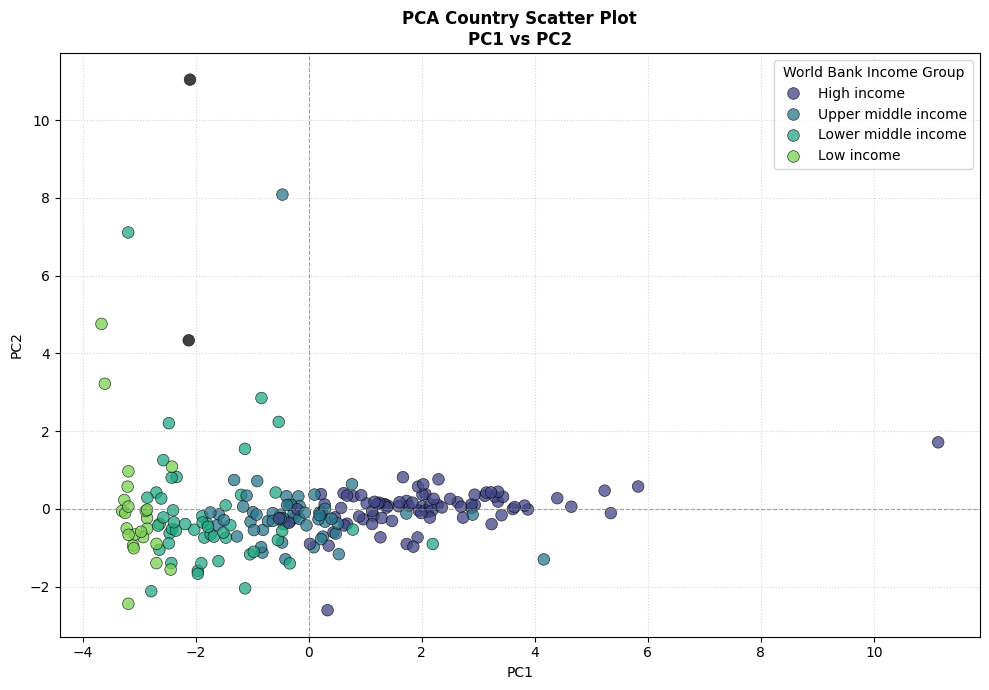

In [52]:
pc_scores = pca_model.transform(df_pca_input)

# Build scores DataFrame
df_scores = pd.DataFrame(
    pc_scores[:, :2], 
    columns=['PC1_Score', 'PC2_Score'], 
    index=df_snapshot['Country Code']
).reset_index()

# Merge metadata (Country Name and Income Group) 
df_visualization = pd.merge(
    df_snapshot[['Country Code', 'Country Name', 'Income Group']], 
    df_scores, 
    on='Country Code'
)

plt.figure(figsize=(10, 7))

income_order = ['High income', 'Upper middle income', 'Lower middle income', 'Low income']
valid_order = [group for group in income_order if group in df_visualization['Income Group'].unique()]

sns.scatterplot(
    data=df_visualization,
    x='PC1_Score',
    y='PC2_Score',
    hue='Income Group',
    hue_order=valid_order,
    palette='viridis',
    alpha=0.75,
    s=70,
    edgecolor='black',
    linewidth=0.5
)

plt.axhline(y=0.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.axvline(x=0.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

plt.title("PCA Country Scatter Plot\nPC1 vs PC2", fontsize=12, fontweight='bold')
plt.xlabel("PC1", fontsize=10)
plt.ylabel("PC2", fontsize=10)
plt.legend(title="World Bank Income Group", loc='best', frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

save_scatter_path = os.path.join(output_figure_dir, "pca_country_scatter.png")
plt.savefig(save_scatter_path, dpi=300)
plt.show()
plt.close()

### 4.5.5 Interpretation of the PCA Space 

The PCA scatter plot shows a clear pattern along the PC1 axis. High-income countries are mostly located on the right-hand side, while lower-income countries are concentrated on the left. This suggests that PC1 captures a strong development-related gradient across the dataset.

In contrast, PC2 does not clearly separate income groups. Most countries are clustered around zero, with a few extreme outliers, indicating that this component captures variation within countries rather than systematic differences between groups.

Overall, the results show a clear horizontal structure in the data driven by PC1, while vertical variation along PC2 is weaker and less structured.

In [67]:
loadings = pd.DataFrame(
    pca_model.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_features))],
    index=pca_features
)

print("=======================================================================")
print("                 PCA LOADING SCORES (PC1-PC5)                         ")
print("=======================================================================")
# First 5 principal components selected using Kaiser criterion
print(loadings[['PC1', 'PC2', 'PC3', 'PC4', 'PC5']].round(4))
print("=======================================================================")

                 PCA LOADING SCORES (PC1-PC5)                         
                             PC1     PC2     PC3     PC4     PC5
credit_to_private_sector  0.3565 -0.0016  0.1370 -0.0427 -0.0268
fdi_inflows              -0.0502 -0.0164  0.3143  0.7743 -0.1909
market_capitalisation     0.2590  0.0606  0.4908 -0.1829 -0.0303
broadband_subscriptions   0.3695  0.0298 -0.2698  0.1403 -0.0063
internet_usage_rate       0.3491  0.0001 -0.2156  0.2375 -0.0241
secure_servers_density    0.1334  0.0198 -0.0260 -0.2604 -0.1318
rd_expenditure            0.3242  0.0194 -0.2794 -0.2807  0.1091
gdp_growth               -0.0252 -0.2475  0.0851  0.1496  0.7901
inflation_rate           -0.1019  0.6228 -0.0063  0.0359  0.1689
real_interest_rate        0.0036 -0.5905  0.0019 -0.0651 -0.3961
capital_formation         0.0473 -0.4269 -0.0388  0.0382  0.3106
tertiary_enrollment       0.3419  0.1087 -0.1612  0.2601 -0.0800
labor_productivity        0.3616  0.0001 -0.1916  0.1578  0.0402
high_tech_exports  

- **PC1**: Strongly linked with finance, digital access, education, and productivity. This mainly shows the overall level of development across countries.
- **PC2**: Mostly driven by inflation, real interest rates, and capital formation. This reflects price conditions and cost of borrowing in the economy.
- **PC3**: Mainly related to market size, ICT imports, and high-tech exports. This captures how connected a country is to global trade and markets.
- **PC4**: Mostly influenced by FDI inflows, with some digital and innovation factors mixed in. This shows differences in countries that rely more on foreign investment.
- **PC5**: Mainly driven by GDP growth, with smaller contributions from other variables. This reflects short-term changes in economic output.